## Diffusione del calore in una barra

Supponiamo che una barra di metallo di lunghezza $L$ a partire dall'istante temporale $t_0$ venga riscaldata alle estremità.

Vogliamo studiare la temperatura in ogni punto della barra negli istanti successivi.

Per dare una risposta numerica al problema, occorre rappresentarlo in forma **discretizzata**
1. definiamo un intervallo temporale di osservazione $[0,T]$ e lo partizioniamo uniformemente in $m$ parti

    $$t_j = j\Delta t , \ \ j=0,...,m$$

    dove $\Delta t =T/m$;

2. partizioniamo uniformemente l'intervallo $[0,L]$, rappresentante la barra, in $n$ parti
    
    $$s_i = i\Delta s, \ \ i=0,...,n$$
    
    dove $\Delta s = L/n$;

3. indichiamo con $U_i(t_j)$ la temperatura della barra nel punto $s_i$, all'istante $t_j$;

4. assumiamo che la temperatura della barra all'istante iniziale alle estremità della barra $U_0(t_j),U_n(t_j)$ sia nota per ogni $j=0,...,m$.

Applicando la legge di diffusione del calore nel discreto, la temperatura $U_i(t_j)$ dipende dalla temperatura nello stesso punto all'istante precedente e dai valori della temperatura nei due punti adiacenti nello stesso istante secondo la formula seguente:

$$\frac{U_i(t_j) - U_i(t_{j-1})}{\Delta t} = \alpha \frac{U_{i-1}(t_j)-2U_i(t_j) +U_{i+1}(t_j)}{\Delta s^2} $$

dove $\alpha$ è il coefficiente di diffusività termica del materiale di cui è costituita la barra, che supponiamo essere noto e uguale in tutti i punti della barra.

Tenendo conto che $U_0(t_j), U_n(t_j)$ sono noti per tutti i $j$, si vogliono calcolare i vettori

$$U(t_j) = \begin{pmatrix}U_1(t_j)\\ \vdots\\ U_{n-1}(t_j) \end{pmatrix} , \ \ j=1,...,m$$

Osserviamo che la legge di diffusione del calore nel discreto, per $j$ fissato, si può riscrivere come

$$-aU_{i-1}(t_j) + (1+2a)U_i(t_j)-aU_{i+1}(t_j) = U_i(t_{j-1}) $$

dove $a = \alpha\Delta t/\Delta s^2$ (numero di Fourier).

Per chiarire possiamo vedere le temperature ignote come incognite e riscrivere la formula come

$$-a\textcolor{red}{x_{i-1}} + (1+2a)\textcolor{red}{x_i} -a\textcolor{red}{x_{i+1}} = b_i $$

sapendo che il termine $b_i$ è noto perchè calcolato all'iterazione precedente.

Se consideriamo tutte le uguaglianze precedenti per $i=1,...,n-1$ e tenendo presente che le temperature alle estremità della barra sono note per ogni $j$, si costruisce un sistema lineare nelle incognite $U_1(t_j),...,U_{n-1}(t_j)$, la cui matrice dei coefficienti e il termine noto sono definiti nel modo seguente
$$A = \begin{pmatrix}
1+2a &-a & \\
-a & 1+2a & -a \\
...\\
\\
& & & -a& 1+2a & -a\\
& & &   & -a & 1+2a
\end{pmatrix} $$
$$
b = \begin{pmatrix}
U_0(t_j) + aU_1(t_{j-1})\\
U_2(t_{j-1})\\
\vdots\\
\\
U_{n-2}(t_{j-1})\\
U_{n-1}(t_{j-1}) + aU_{n}(t_j)
\end{pmatrix}$$

Per ottenere la temperatura della barra negli $m$ istanti temporali $t_1,...,t_m$ dovremo quindi risolvere in sequenza $m$ sistemi lineari con la struttura che abbiamo descritto qui sopra.



**Metodo di Jacobi per il sistema della diffusione del calore**
$$Ax=b $$
Osserviamo che la matrice $A$ è strettamente diagonale dominante per righe, pertanto il metodo di Jacobi è convergente per questo sistema.

Inoltre, la struttura della matrice permette una implementazione semplificata della formula di aggiornamento.

Infatti, la $i$-esima equazione del sistema è
$$  -ax_{i-1}+(1+2a)x_i-ax_{i+1} =b_i$$
La formula di aggiornamento componente per componente diventa
  $$x_i^{(k+1)} = \frac{b_i + a(x_{i-1}^{(k)}+x_{i+1}^{(k)})}{1+2a} $$
  In questo caso è anche ragionevole inizializzare le iterate del metodo di Jacobi con il termine noto, che è il profilo termico all'istante temporale precedente.


In [1]:
import numpy as np

# ============================================================
# 1. PARAMETRI DEL MODELLO (EQUAZIONE DEL CALORE 1D)
# ============================================================

L = 1.0          # Lunghezza della barra (m)
n = 51           # Numero di punti spaziali
dx = L / n       # Passo spaziale

alpha = 0.05     # Coefficiente di diffusività termica
T = 10           # Tempo totale di simulazione
m = 100          # Numero di passi temporali
dt = T / m       # Passo temporale

# Numero di Fourier (parametro chiave dello schema numerico)
a = alpha * dt / dx**2

# ============================================================
# 2. CONDIZIONI INIZIALI
# ============================================================

u0 = np.zeros(n)
u0[0] = 100.0     # Estremo sinistro (temperatura fissata)
u0[-1] = 0.0      # Estremo destro (temperatura fissata)

# ============================================================
# 3. METODO DI JACOBI (RISOLUZIONE SISTEMA LINEARE)
# ============================================================

def jacobi(b, a, tol=1e-4, Nmax=1000):
    """
    Risolve il sistema lineare derivante dallo schema implicito
    usando il metodo iterativo di Jacobi.

    Parametri:
        b     : termine noto (vettore al tempo precedente)
        a     : parametro di Fourier
        tol   : tolleranza per il criterio di arresto
        Nmax  : numero massimo di iterazioni

    Ritorna:
        x_new : soluzione approssimata
        k     : numero di iterazioni effettuate
    """

    # Inizializzazione: partiamo da una stima iniziale
    x = b.copy()
    x_new = b.copy()

    for k in range(Nmax):

        # Aggiornamento SOLO dei punti interni (i bordi sono fissati)
        x_new[1:-1] = (
            b[1:-1] + a * (x[:-2] + x[2:])
        ) / (1 + 2 * a)

        # Criterio di arresto: differenza tra iterazioni successive
        if np.linalg.norm(x_new - x) < tol:
            break

        x = x_new.copy()

    return x_new, k

# ============================================================
# 4. METODO DI GAUSS-SEIDEL (RISOLUZIONE SISTEMA LINEARE)
# ============================================================

def gauss_seidel(b, a, tol=1e-4, Nmax=1000):
    """
    Metodo di Gauss-Seidel per il sistema tridiagonale
    derivante dall'equazione del calore 1D.
    """

    x = b.copy()   # stima iniziale

    for k in range(Nmax):

        x_old = x.copy()

        # aggiornamento sequenziale (uso valori già aggiornati!)
        for i in range(1, len(b) - 1):
            x[i] = (
                b[i] + a * (x[i-1] + x_old[i+1])
            ) / (1 + 2 * a)

        # criterio di arresto
        if np.linalg.norm(x - x_old) < tol:
            break

    return x, k

In [2]:
# ============================================================
# 5. EVOLUZIONE TEMPORALE JACOBI
# ============================================================

# Matrice che contiene la soluzione nel tempo
U = np.zeros((m + 1, n))
U[0, :] = u0

tot_iter = 0  # contatore totale iterazioni Jacobi

for i in range(m):
    # Risolviamo il sistema al tempo successivo
    u_next, k = jacobi(U[i, :], a)

    U[i + 1, :] = u_next
    tot_iter += k

print(f"Numero totale di iterazioni Jacobi: {tot_iter}")

Numero totale di iterazioni Jacobi: 15774


In [3]:
# ============================================================
# 6. EVOLUZIONE TEMPORALE GAUSS-SEIDEL
# ============================================================

# Matrice che contiene la soluzione nel tempo
U = np.zeros((m + 1, n))
U[0, :] = u0

tot_iter = 0  # contatore totale iterazioni gauss-seidel

for i in range(m):
    # Risolviamo il sistema al tempo successivo
    u_next, k = gauss_seidel(U[i, :], a)

    U[i + 1, :] = u_next
    tot_iter += k

print(f"Numero totale di iterazioni Gauss-Seidel: {tot_iter}")

Numero totale di iterazioni Gauss-Seidel: 8843


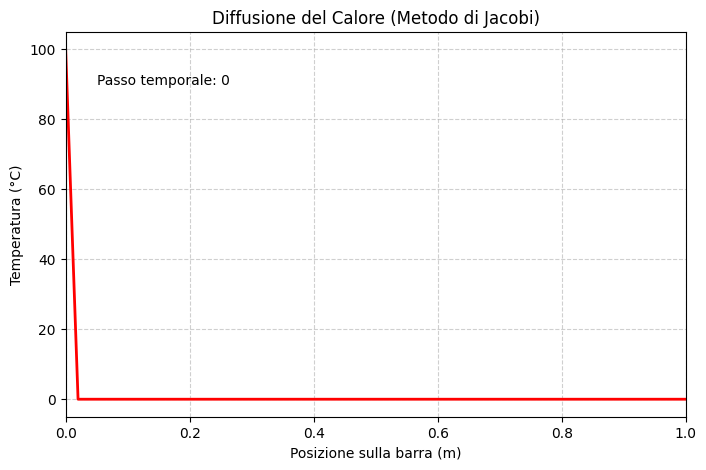

In [4]:
# --- 3. VISUALIZZAZIONE GRAFICA ---
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(8, 5))
x = np.linspace(0, L, n)
line, = ax.plot(x, u0, lw=2, color='red')

ax.set_ylim(-5, 105)
ax.set_xlim(0, L)
ax.set_title("Diffusione del Calore (Metodo di Jacobi)")
ax.set_xlabel("Posizione sulla barra (m)")
ax.set_ylabel("Temperatura (°C)")
ax.grid(True, linestyle='--', alpha=0.6)


# Testo nel grafico
time_text = ax.text(0.05, 90, '', fontsize=10)
time_text.set_text(f"Passo temporale: {0}")


def init_func():
  line.set_ydata(u0)        # Aggiorna il grafico
  time_text.set_text(f"Passo temporale: {0}")
  return line,

# --- 4. FUNZIONE PER L'ANIMAZIONE ---
def update(frame):
    if frame == 0:
      return line, time_text
    u   = line.get_ydata()
    u,_ = jacobi(u, a)  # Calcola il profilo termico al tempo successivo
    line.set_ydata(u)        # Aggiorna il grafico
    time_text.set_text(f"Passo temporale: {frame+1}")
    return line, time_text


# Creazione dell'animazione
# frames: numero di passi temporali, interval: millisecondi tra i frame
ani = FuncAnimation(fig, update, frames=m, init_func=init_func, interval=50, blit=True)

plt.show()

In [5]:
from IPython.display import HTML

# Trasforma l'animazione in un video HTML5 e lo visualizza
HTML(ani.to_jshtml())